In [2]:
!pip install -r ../requirements.txt


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


| 컬럼명 | 설명 |
| --- | --- |
| `hotel` | 호텔명 (`Resort Hotel` 혹은 `City Hotel`) |
| `is_canceled` | 호텔 예약이 취소되었는지(1) 혹은 취소되지 않았는지(0)를 나타내는 값 |
| `lead_time` | 호텔 예약 시점부터 고객의 호텔 도착 시점까지의 기간 (단위: 날짜) |
| `arrival_date_year` | 고객의 호텔 도착 연도 |
| `arrival_date_month` | 고객의 호텔 도착 월 |
| `arrival_date_week_number` | 고객의 호텔 도착 주 <br> 예: 2015년도 셋째 주에 도착 → `arrival_date_week_number = 3` |
| `arrival_date_day_of_month` | 고객의 호텔 도착 일 <br> 예: 3월 2일에 도착 → `arrival_date_day_of_month = 2` |
| `stays_in_weekend_nights` | 고객이 호텔에 숙박했거나 예약한 주말 밤 수(토요일~일요일) <br> 예: 평일 3일, 주말 2일 예약 → `stays_in_weekend_nights = 2` |
| `stays_in_week_nights` | 고객이 호텔에 숙박했거나 예약한 주중 밤 수(월요일~금요일) <br> 예: 평일 3일, 주말 2일 예약 → `stays_in_week_nights = 3` |
| `adults` | 예약된 어른의 수 |
| `children` | 예약된 어린이의 수 |
| `babies` | 예약된 아기의 수 |
| `meal` | 예약된 식사 유형 <br> - `Undefined/SC`: 식사가 포함되지 않은 옵션 <br> - `BB`: Bed & Breakfast 옵션 <br> - `HB`: Half Board (아침 식사 및 추가 식사 1회, 일반적으로 저녁 식사) 옵션 <br> - `FB`: Full Board (아침, 점심, 저녁) |
| `country` | 투숙객의 출신 국가. 카테고리는 ISO 3155-3:2013 형식으로 표시 |
| `market_segment` | 시장 세그먼트. `TA`는 Travel Agent, `TO`는 Tour Operators를 의미 |
| `distribution_channel` | 예약 유통 채널. `TA`는 Travel Agent, `TO`는 Tour Operators를 의미 |
| `is_repeated_guest` | 이전에 방문했던 손님인지(1) 아닌지(0)를 나타내는 값 |
| `previous_cancellations` | 현재 예약 이전에 고객이 취소한 이전 예약 수 |
| `previous_bookings_not_canceled` | 현재 예약 이전에 고객이 취소하지 않은 이전 예약 수 |
| `reserved_room_type` | 예약한 룸 타입 코드 |
| `assigned_room_type` | 실제 배정된 룸 타입 코드. 호텔 운영상의 이유(예: 초과 예약 등) 또는 고객 요청으로 인해 예약한 객실과 다른 객실 유형이 배정되는 경우가 존재 |
| `booking_changes` | 예약 시점부터 예약 취소 또는 체크인 시점까지 예약에 대한 변경/수정 횟수 |
| `agent` | 예약을 진행한 여행사의 ID |
| `company` | 예약을 하였거나 예약금을 지불할 책임이 있는 회사 또는 단체의 ID |
| `days_in_waiting_list` | 예약이 확정되기 전까지 해당 예약이 예약 대기자 명단에 있었던 일수 |
| `required_car_parking_spaces` | 고객이 요구하는 주차 공간 수 |
| `total_of_special_requests` | 고객의 특별 요청 건수 (예: 트윈 베드, 아기 침대, 고층, 특별한 뷰 등) |
| `reservation_status` | 예약의 마지막 상태 <br> - `Canceled`: 고객이 예약을 취소함 <br> - `Check-Out`: 고객이 체크인을 하고 체크아웃함 <br> - `No-Show`: 고객이 체크인을 하지 않았고 해당 이유를 알 수 없음 |
| `reservations_status_date` | 마지막 예약 상태(`reservation_status`)가 설정된 날짜 |

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../data/hotel_data_modified.csv')

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,C,3,NaN,NaN,0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,C,4,NaN,NaN,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,A,C,0,NaN,NaN,0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,A,0,304.0,NaN,0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,A,0,240.0,NaN,0,0,1,Check-Out,2015-07-03


In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,8.000000,5.000000


In [6]:
# 값이 비어 있는 열이 company, agent -> company나 agent가 비어 있는 열은 개인 예약 고객
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

### 데이터 안에 NULL 처리
`country`,`agent`,`company`에 null 값이 존재함을 인지함.<br>
`country`가 왜 비었는지 알 수 없으므로 Unknown으로 인지하고 0으로 처리함.<br>
`agent`와 `company`는 정수 데이터이므로 비어 있는 곳은 일단 오류 방지를 위해 0으로 처리함.<br>
`children`도 왜 비었는지 알 수 없지만, 정수 데이터로 아이들의 숫자이기에 0으로 처리함.<br>
`reservation_status_date`는 datetime type으로 변환

In [7]:
clean_df = df.copy()
# country, agent, company에서 비어 있는 값 발견하여, country는 고객이 공개하기 싫어 조사 거부로 생각하
clean_df = clean_df.fillna(0)
clean_df.isna().sum()
clean_df['reservation_status_date'] = pd.to_datetime(clean_df['reservation_status_date'])
clean_df['market_segment'].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

### 호텔별 취소율 분석

1. 전체 취소 건수 중에 호텔 별로 얼마나 차지
확인 결과: City Hotel 74.9%, Resort Hotel 25.1%로 City Hotel이 앞도적으로 높은 것을 확인

2. 호텔별 전체 예약 건수 중 취소율이 몇 퍼센트인가
확인 결과: City Hotel canceled 41.7%, Resort Hotel 27.8%로 City Hotel이 예약건수 대비 취소율이 높은 것을 확인

전체 취소 건수가 높아, 단순히 City Hotel이 예약건수가 많아서 인지 확인하기 위해 호텔 별 예약 건수 중 취소율을 확인하였을 때도 City Hotel 취소율이 더 높은 것을 확인하여 City Hotel이 취소율이 높은 호텔이라는 것을 인지하였습니다. 이 데이터 범위에서는 City Hotel의 취소율이 더 높게 관찰되지만, 호텔 유형 자체가 취소의 원인이라고 단정할 수는 없다.

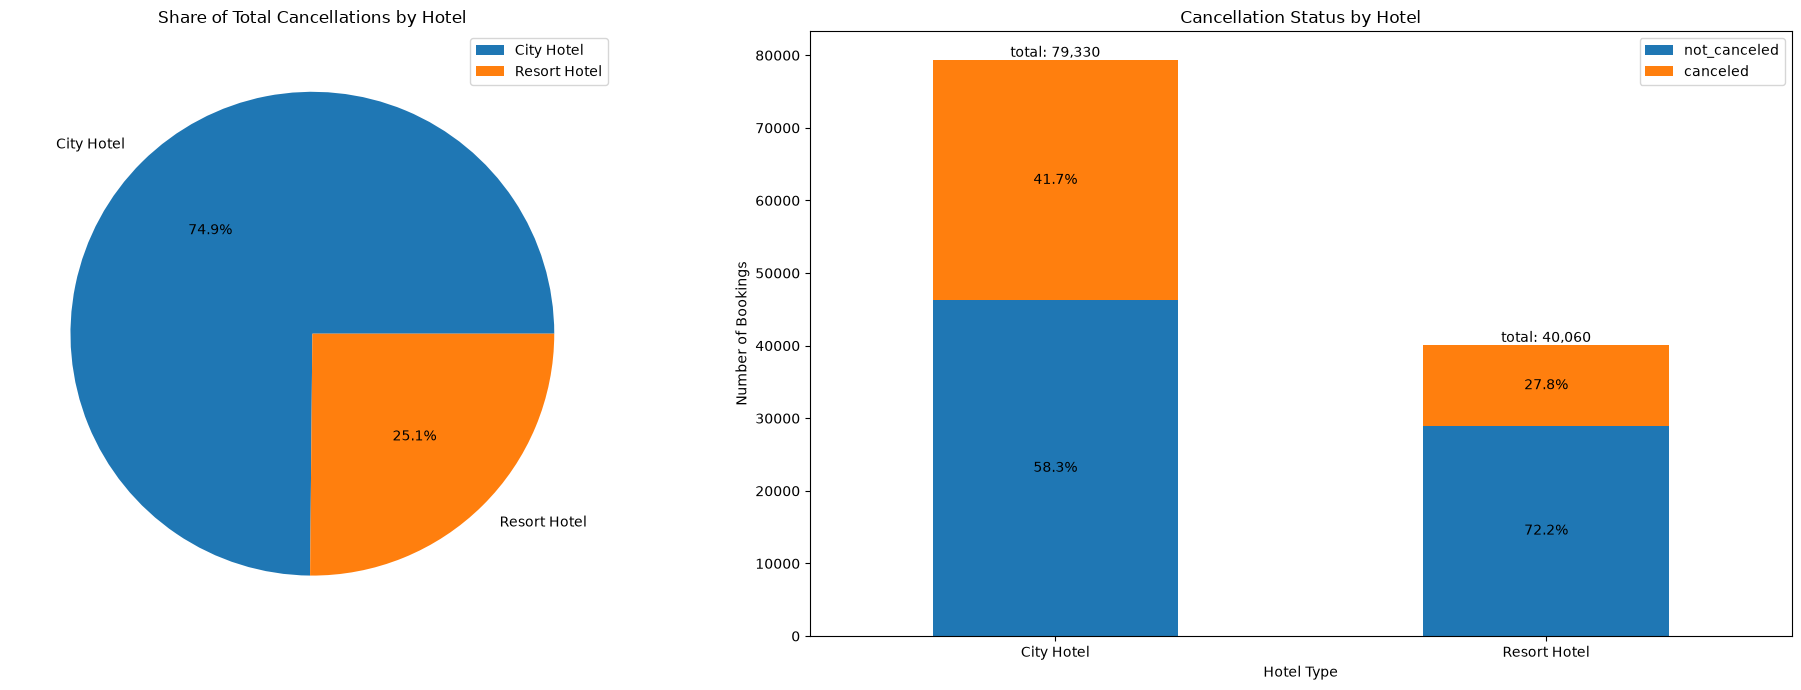

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

hotel_by_cancel_summary =(
    clean_df
        .groupby('hotel')['is_canceled']
        .agg(['count', 'sum'])
)
canceled = hotel_by_cancel_summary['sum']
total_booking =hotel_by_cancel_summary['count']
not_canceled = total_booking - canceled


hotel_by_is_cancel = pd.DataFrame(
    data={
            'not_canceled': not_canceled,
            'canceled': canceled
            },
    index=hotel_by_cancel_summary.index,
    columns=['not_canceled', 'canceled']
    )

hotel_by_is_cancel_per = pd.DataFrame(
    data={
            'not_canceled': not_canceled / total_booking,
            'canceled': canceled / total_booking
            
            },
    index=hotel_by_cancel_summary.index,
    columns=['not_canceled', 'canceled']
)


# hotel_by_cancel_summary['sum']
axes[0].pie(hotel_by_cancel_summary['sum'], labels=hotel_by_cancel_summary.index, autopct='%.1f%%')
axes[0].set_title('Share of Total Cancellations by Hotel')
axes[0].set_title('Share of Total Cancellations by Hotel')

axes[1].set_title('Cancellation Status by Hotel')


ax_1 = hotel_by_is_cancel.plot(
    kind='bar',
    stacked=True,
    ax=axes[1]
)

axes[1].set_title('Cancellation Status by Hotel')
axes[1].tick_params(axis='x', labelrotation=0)
axes[1].set_ylabel('Number of Bookings')
axes[1].set_xlabel('Hotel Type')

for container, column_name in zip(
    ax_1.containers, 
    hotel_by_is_cancel_per
):
    
    # ax_1.bar_label(container)
    labels = [
        f'{value:.1%}'
        for value in hotel_by_is_cancel_per[column_name]
    ]
    # print(labels)

    ax_1.bar_label(
        container,
        labels=labels,
        label_type='center'
    )

for i, total in enumerate(total_booking):
    ax_1.text(
        i,
        total,
        f'total: {total:,}',
        ha='center',
        va='bottom'
    )

axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()


### 고객 예약 유형 별 취소
`market_segment`에 따른 취소 건수를 확인하였을 때 Online TA가 20,739건으로 1등, Groups가 12,097건으로 2등이다.<br>
따라서, 이 데이터로는 Online TA가 예약 건수가 많아 취소 건수 자체가 많다고 보이지지만, 실제로 비율을 따져봤을 때는 Groups가 61.1%의 취소율을 보여줌에 따라 이는 오히려 Group으로 예약했을 때 취소율이 높다고 판단할 수 있다.<br>
두 호텔 모두 Groups에서 취소율이 가장 높고, Direct와 Corporate는 비교적 낮다. Offline TA/TO 이후의 선 모양은 다름. City Hotel은 비교적 높은 수준을 유지하지만 Resort Hotel은 크게 낮아졌다가 Online TA에서 다시 상승함
Other는 1000건의 이하의 전체 예약 건들로 `Complementary`, `Aviation`, `Undefined`이다.

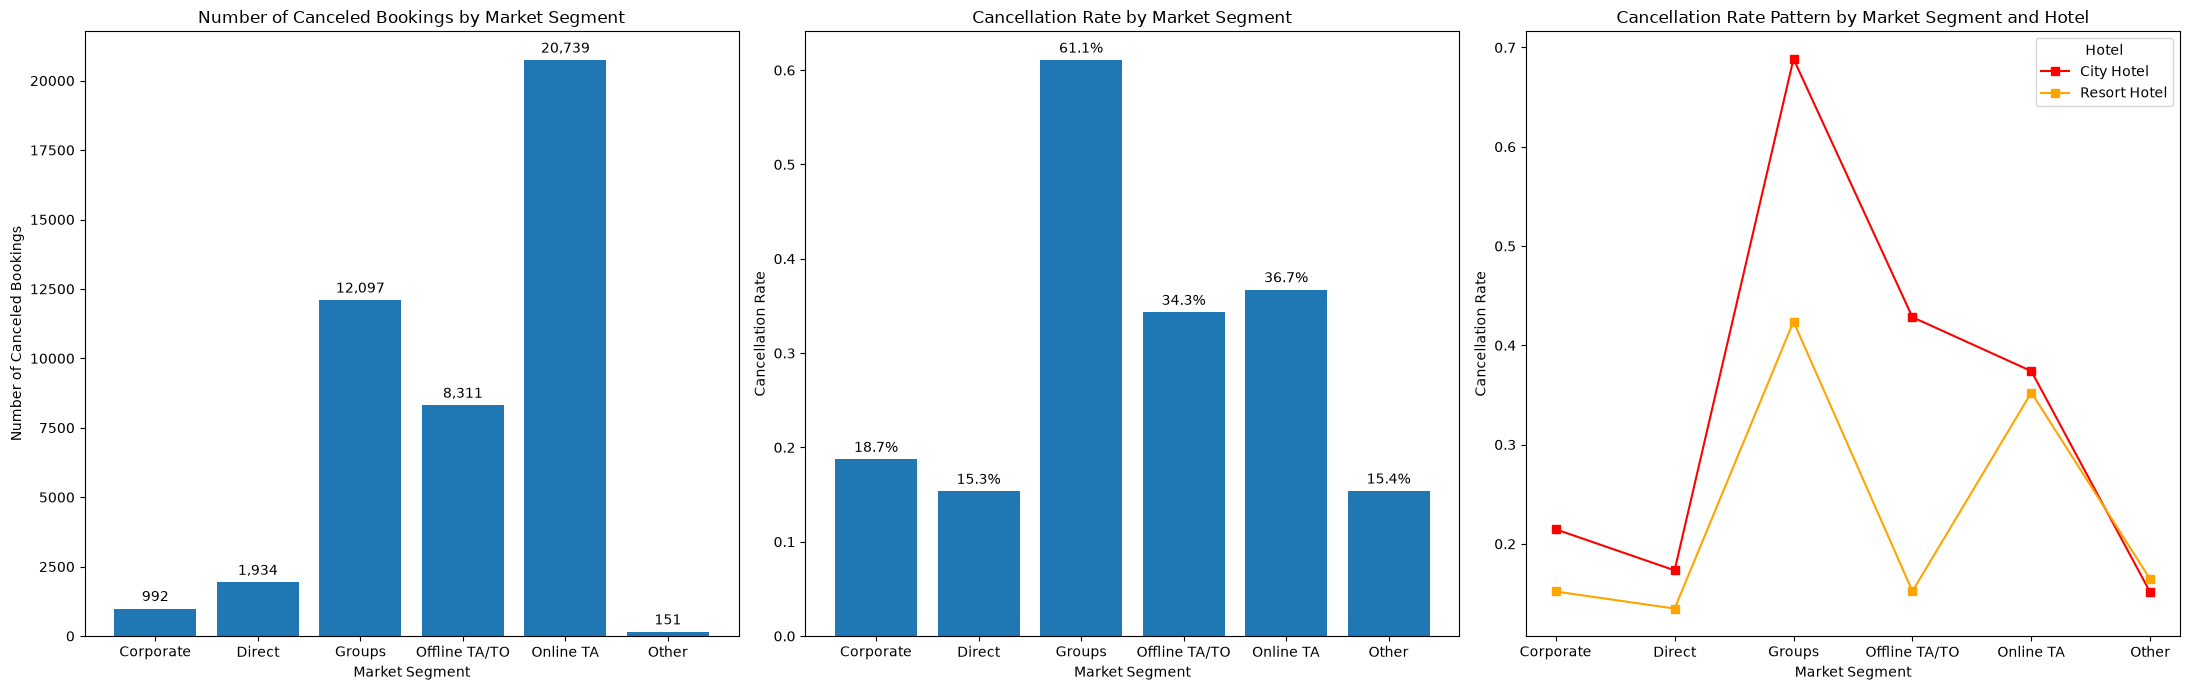

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(22,7))

def group_summary(data):
    return (
        data
                .groupby('market_segment')['is_canceled']
                .agg(['count', 'sum'])
    )

def concat_data(main_data, other_data):
    return pd.concat(
        [
            main_data,
            pd.Series({'Other': other_data}),
        ]
    )

def get_cancel_rate(summary):
    return(
        summary['sum'] 
        / 
        summary['count']
    )

def get_other_cancel_rate(summary):
    return (
        summary['sum'].sum()
        /
        summary['count'].sum()
    )

def smaller_thousand_summary_count_mask(summary):
    return summary['count'] <= 1000

def filter_summary(summary, mask):
    return summary.loc[mask]

# 전체 market_segment별 취소율
market_segment_by_canceled_summary = group_summary(clean_df)

m_smaller_mask = smaller_thousand_summary_count_mask(market_segment_by_canceled_summary)

market_segment_by_canceled_summary['canceled_rate'] = get_cancel_rate(market_segment_by_canceled_summary)

main_summary = filter_summary(market_segment_by_canceled_summary, ~m_smaller_mask)
other_summary = filter_summary(market_segment_by_canceled_summary, m_smaller_mask)

other_cancel_rate = get_other_cancel_rate(other_summary)

all_canceled_graph = concat_data(main_summary['sum'], other_summary['sum'].sum())

canceled_graph_df = concat_data(main_summary['canceled_rate'], other_cancel_rate)

order = canceled_graph_df.index

all_canceled_graph = all_canceled_graph.loc[order]

# city hotel의 market segment 별 취소율

hotel_mask = clean_df['hotel'] == 'City Hotel'
city_hotel = clean_df.loc[hotel_mask]
resort_hotel = clean_df.loc[~hotel_mask]

city_hotel_market_segment_summary = group_summary(city_hotel)

ch_smaller_mask = smaller_thousand_summary_count_mask(city_hotel_market_segment_summary)

city_hotel_market_segment_summary['canceled_rate'] = get_cancel_rate(city_hotel_market_segment_summary)

ch_main_summary = filter_summary(city_hotel_market_segment_summary, ~ch_smaller_mask)
ch_other_summary = filter_summary(city_hotel_market_segment_summary, ch_smaller_mask)

ch_other_cancel_rate = get_other_cancel_rate(ch_other_summary)

ch_canceled_graph_df = concat_data(ch_main_summary['canceled_rate'], ch_other_cancel_rate)

# resort hotel의 market segment 별 취소율
resort_hotel_market_segment_summary = group_summary(resort_hotel)

rh_smaller_mask = smaller_thousand_summary_count_mask(resort_hotel_market_segment_summary)

resort_hotel_market_segment_summary['canceled_rate'] = get_cancel_rate(resort_hotel_market_segment_summary)

rh_main_summary = filter_summary(resort_hotel_market_segment_summary, ~rh_smaller_mask)
rh_other_summary = filter_summary(resort_hotel_market_segment_summary, rh_smaller_mask)

rh_other_cancel_rate = get_other_cancel_rate(rh_other_summary)

rh_canceled_graph_df = concat_data(rh_main_summary['canceled_rate'], rh_other_cancel_rate)


bars_1 = axes[1].bar(canceled_graph_df.index, canceled_graph_df.values)
axes[2].plot(ch_canceled_graph_df.index, ch_canceled_graph_df.values, color='red',linestyle='-',marker='s')
axes[2].plot(rh_canceled_graph_df.index, rh_canceled_graph_df.values, color='orange',linestyle='-',marker='s')

bars_2 = axes[0].bar(all_canceled_graph.index, all_canceled_graph.values)

axes[1].bar_label(bars_1, fmt='{:,.1%}', padding=3)


axes[0].bar_label(bars_2, fmt='{:,.0f}', padding=3)

# axes[0].spines['bottom'].set_visible(False)

# 예약 유형별 취소 건수
axes[0].set_title('Number of Canceled Bookings by Market Segment')
axes[0].set_xlabel('Market Segment')
axes[0].set_ylabel('Number of Canceled Bookings')

# 전체 예약 유형별 취소율
axes[1].set_title('Cancellation Rate by Market Segment')
axes[1].set_xlabel('Market Segment')
axes[1].set_ylabel('Cancellation Rate')

# 호텔별 예약 유형의 취소율 패턴
axes[2].set_title('Cancellation Rate Pattern by Market Segment and Hotel')
axes[2].set_xlabel('Market Segment')
axes[2].set_ylabel('Cancellation Rate')

axes[2].legend(
    ['City Hotel', 'Resort Hotel'],
    title='Hotel'
)
plt.tight_layout()

plt.show()


### 고객들의 예약 시기 흐름
`lead_time`이 **181일 이후**로 취소율이 급격히 상승하는 것을 알 수가 있었다.<br>
`lead_time`이 길수록 취소율이 높아지고, **181일이 넘어가는 예약**은 취소율은 평균 50%가 넘어가는 확인하였다.<br>
반면에 `lead_time`이 0-30구간에서는 다른 구간보다 낮다는 것을 확인할 수 있었다.

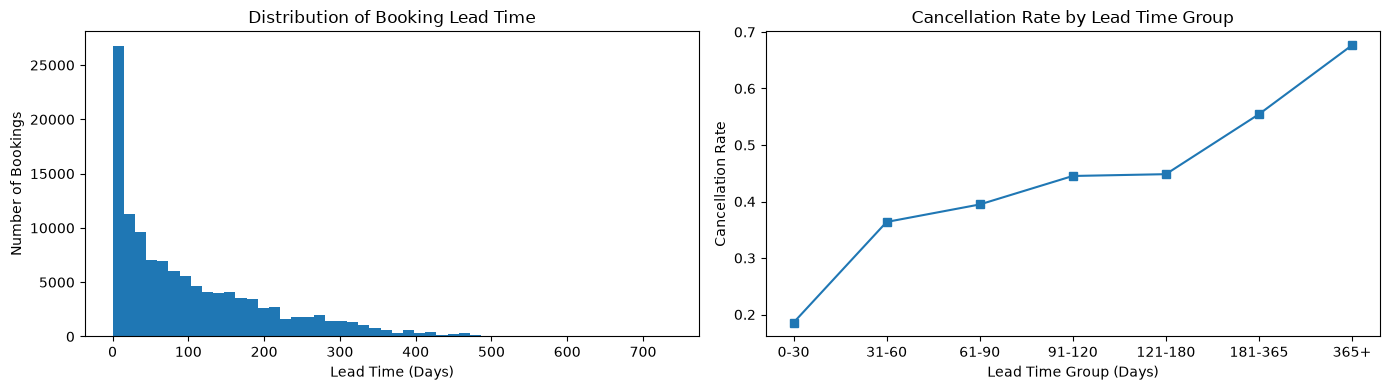

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))


lead_time = clean_df['lead_time']

axes[0].hist(lead_time, bins=50)

reserved_duration_bins = [-1, 30, 60, 90, 120, 180, 365, float('inf')]

reserved_duration_section_labels = [
    '0-30',
    '31-60',
    '61-90',
    '91-120',
    '121-180',
    '181-365',
    '365+'
]


lead_time_canceled_summary = (
    clean_df
        .assign(lead_time_group=pd.cut(lead_time, bins=reserved_duration_bins, labels=reserved_duration_section_labels, right=True))
        .groupby('lead_time_group')['is_canceled']
        .mean()
)



axes[1].plot(lead_time_canceled_summary.index.categories, lead_time_canceled_summary.values, marker='s')

axes[0].set_title('Distribution of Booking Lead Time')
axes[0].set_xlabel('Lead Time (Days)')
axes[0].set_ylabel('Number of Bookings')

axes[1].set_title('Cancellation Rate by Lead Time Group')
axes[1].set_xlabel('Lead Time Group (Days)')
axes[1].set_ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

### 상위 10위 예약 국가

| 국가 코드(ISO 3자리) | 국가 이름 |
|---|---|
| PRT | 포르투갈 |
| GBR | 영국 |
| FRA | 프랑스 |
| ESP | 스페인 |
| DEU | 독일 |
| ITA | 이탈리아 |
| IRL | 아일랜드 |
| BEL | 벨기에 |
| BRA | 브라질 |
| NLD | 네덜란드 |

예약 국가 중 포루투칼이 48,590건으로 가장 많음을 확인하였습니다.

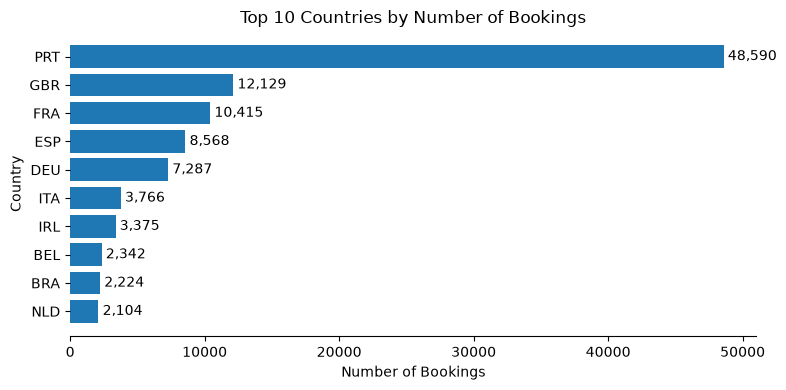

In [47]:
fig, ax = plt.subplots(figsize=(8, 4))

country_value_counts = (
    clean_df['country']
        .value_counts()
        .head(10)
)


bar = ax.barh(country_value_counts.index, country_value_counts.values)

ax.invert_yaxis()

ax.set_title('Top 10 Countries by Number of Bookings')

ax.bar_label(bar, fmt='{:,.0f}', padding=3)
ax.set_xlabel('Number of Bookings')
ax.set_ylabel('Country')

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 국가 및 리드타임 구간별 취소율

다른 나라들에서는 크게 유의미한 것을 확인할 수 없었지만, 포르투칼은 `lead_time`이 31일이 넘어가는 순간부터 취소율이 56.9%를 넘어가면서 나중에 365+ 구간에서는 96.5%로 압도적인 취소율을 보여준다. 단순 퍼센트만 보고 비교하면 안되기 때문에 365+ 구간의 나라들 별 전체 취소 건수를 확인하였을 때 포르투칼은 2202건으로 눈에 띈다.

브라질은 181-365 구간에서 72.2%로 높은 취소율을 보여주지만 TOP10 국가 중에 취소 건수는 273건으로 9위를 기록한 것으로 보아 퍼센트로만은 커보이지만, 다른 나라들에 비해서는 큰 규모가 아님을 확인하였다. 
따라서 포르투칼 쪽 취소관리가 필요해 보인다.


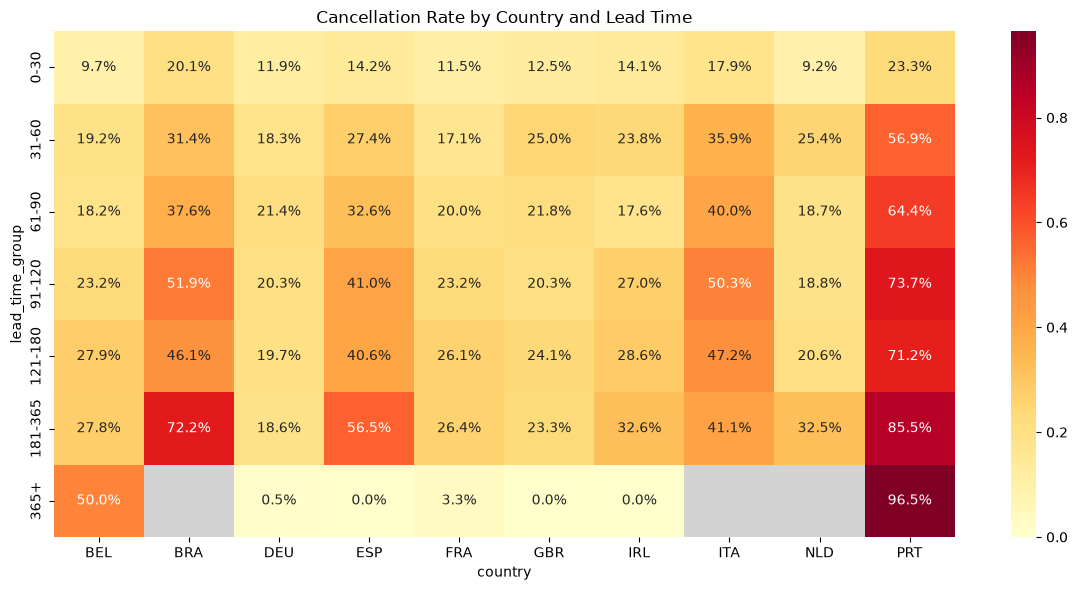

country
PRT        9964
GBR        3065
DEU        1922
FRA        1297
IRL         809
ITA         525
ESP         490
BEL         396
BRA         273
NLD         246
Name: count, dtype: int64

In [48]:
# 수도 코드
# 국가 별 value_counts()로 head(10)을 가져온다.
# lead_time을 ['0-30','31-60','61-90','91-120','121-180','181-365','365+']으로 범위 데이터로 가져온다.
# 리드타임과 국가별 함께 취소 건수를 그룹화한다.
# x: lead_time, y: country, 색은 취소 건수인 히트맵을 그린다.
# 국가와 리드 타임 별로 어떤 취소 관계를 가지는가? 확인한다.

fig, ax = plt.subplots(figsize=(12, 6))


country_top_ten = (
    clean_df['country']
        .value_counts()
        .head(10)
)

country_filter_mask = clean_df['country'].isin(country_top_ten.index)
# country_cancel_top_ten_filter
filtered_df = clean_df[country_filter_mask][['country', 'lead_time', 'is_canceled']].copy()


filtered_df['lead_time_group'] = pd.cut(
    filtered_df['lead_time'],
    bins=reserved_duration_bins,
    labels=reserved_duration_section_labels
)

lead_time_group = (
    filtered_df
        # .assign(lead_time_group=pd.cut(lead_time, bins=reserved_duration_bins, labels=reserved_duration_section_labels, right=True))
        .groupby(['lead_time_group', 'country'], observed=True)['is_canceled']
        .agg(['count', 'sum', 'mean'])
)
heatmap_df = lead_time_group['mean'].unstack()


cmap = plt.cm.YlOrRd.copy()
cmap.set_bad('lightgray')

sns.heatmap(
    heatmap_df,
    cmap=cmap,
    annot=True,
    fmt='.1%',
    ax=ax
)

ax.set_title('Cancellation Rate by Country and Lead Time')
plt.tight_layout()
plt.show()

filtered_thirty_six_five_days = filtered_df.loc[filtered_df['lead_time_group'] == '365+']
filtered_down_one_eight_one_days =filtered_df.loc[filtered_df['lead_time_group'] == '181-365']

filtered_thirty_six_five_days[['country']].value_counts()
filtered_down_one_eight_one_days[['country']].value_counts()

### 예약 변경 횟수와 취소율
`lead_time`에 따른 `booking_changes`를 살펴보았을 때는 대체적으로 비슷한 평균을 보여주어서 `lead_time`에 따른 `booking_changes`변화는 크게 없다고 보여진다.<br>
`booking_changes`를 ['0','1','2','3+']구간으로 나누어보았을 때 전체 취소건수가 많은 곳은 '0' 구간이다.<br>
평균으로 확인하였을 때도 '0'구간이 압도적으로 높다.<br>
이 데이터에서 예약 변경이 없는 예약의 취소율이 더 높게 관찰됐다.

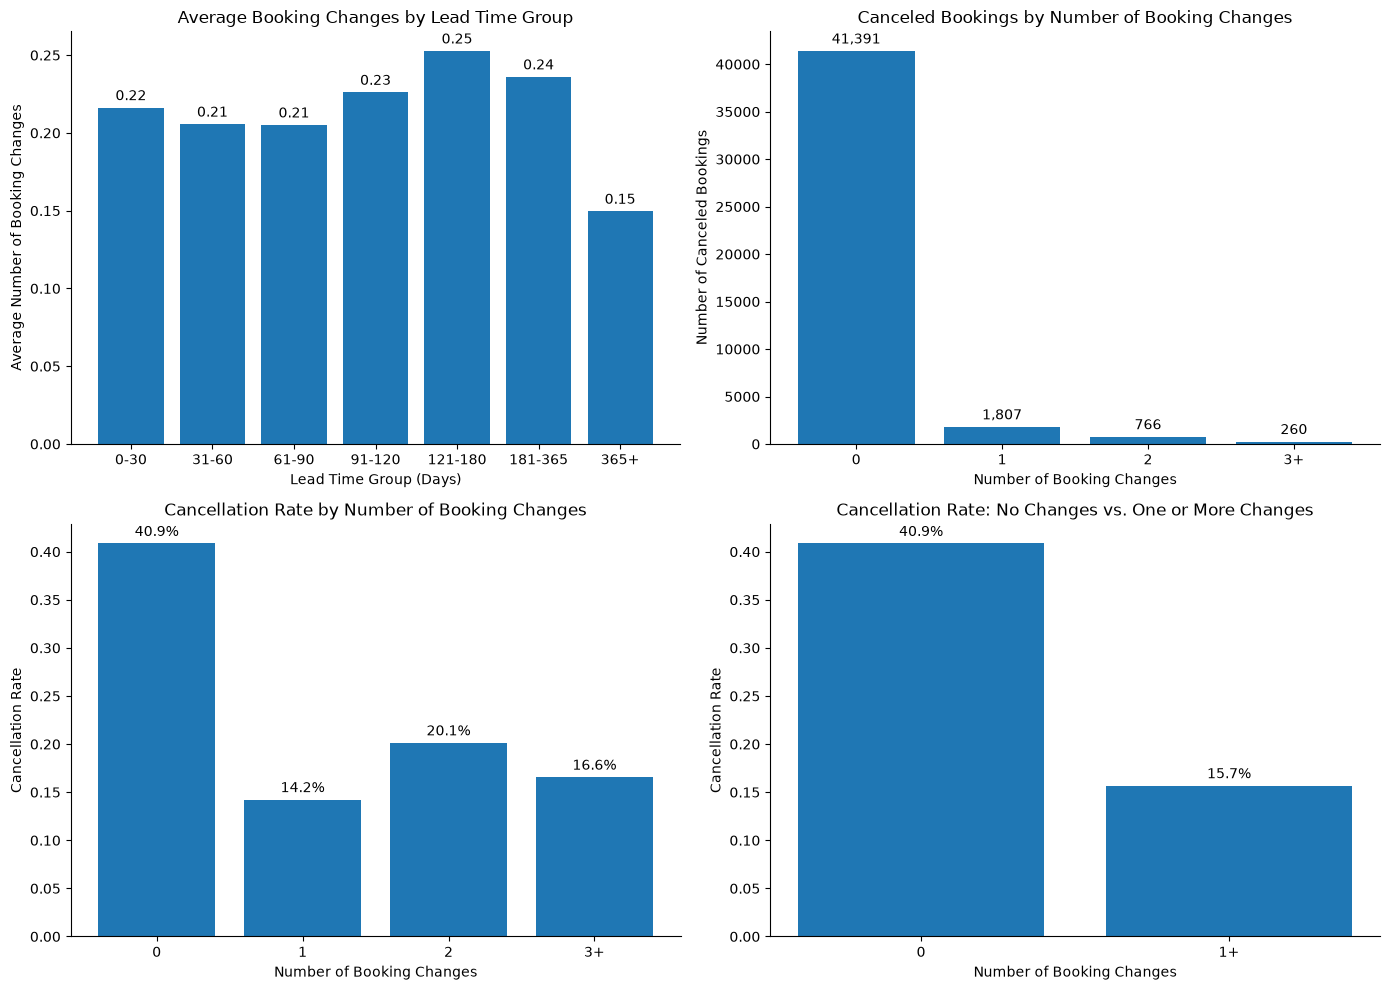

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

filtered_columns = clean_df[['booking_changes', 'is_canceled', 'lead_time']].copy()

lead_time_summary = (
    filtered_columns
        .assign(
            lead_time_group=pd.cut(
                clean_df['lead_time'], 
                bins=reserved_duration_bins, 
                labels=reserved_duration_section_labels, 
                right=True
            )
        )
        .groupby('lead_time_group')['booking_changes']
        .agg(['count', 'sum', 'mean'])
)

bar_1 = axes[0, 0].bar(
    lead_time_summary['mean'].index,
    lead_time_summary['mean'].values
)

axes[0, 0].bar_label(bar_1, fmt='{:,.2f}', padding=3)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)




booking_changes_count_bins = [-1, 0, 1, 2, float('inf')]

booking_changes_count_section_labels = [
    '0',
    '1',
    '2',
    '3+'
]

booking_changes_summary = (
    filtered_columns
        .assign(
            booking_changes_group=pd.cut(
                clean_df['booking_changes'],
                bins=booking_changes_count_bins,
                labels=booking_changes_count_section_labels,
                right=True
            )
        )
        .groupby('booking_changes_group')['is_canceled']
        .agg(['count', 'sum', 'mean'])
)

bar_2 = axes[0, 1].bar(
    booking_changes_summary['sum'].index,
    booking_changes_summary['sum'].values
)

axes[0, 1].bar_label(bar_2, fmt='{:,.0f}', padding=3)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)



bar_3 = axes[1, 0].bar(
    booking_changes_summary['mean'].index,
    booking_changes_summary['mean'].values
)

axes[1, 0].bar_label(bar_3, fmt='{:,.1%}', padding=3)
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)



booking_changes_count_bins_2 = [-1, 0, float('inf')]

booking_changes_count_section_labels_2 = [
    '0',
    '1+'
]

booking_changes_re_group_summary = (
    filtered_columns
        .assign(
            booking_changes_group=pd.cut(
                clean_df['booking_changes'],
                bins=booking_changes_count_bins_2,
                labels=booking_changes_count_section_labels_2,
                right=True
            )
        )
        .groupby('booking_changes_group')['is_canceled']
        .agg(['count', 'sum', 'mean'])
)

bar_4 = axes[1, 1].bar(
    booking_changes_re_group_summary['mean'].index,
    booking_changes_re_group_summary['mean'].values
)

axes[1, 1].bar_label(bar_4, fmt='{:,.1%}', padding=3)
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)


axes[0, 0].set_title('Average Booking Changes by Lead Time Group')
axes[0, 0].set_xlabel('Lead Time Group (Days)')
axes[0, 0].set_ylabel('Average Number of Booking Changes')

axes[0, 1].set_title('Canceled Bookings by Number of Booking Changes')
axes[0, 1].set_xlabel('Number of Booking Changes')
axes[0, 1].set_ylabel('Number of Canceled Bookings')

axes[1, 0].set_title('Cancellation Rate by Number of Booking Changes')
axes[1, 0].set_xlabel('Number of Booking Changes')
axes[1, 0].set_ylabel('Cancellation Rate')

axes[1, 1].set_title('Cancellation Rate: No Changes vs. One or More Changes')
axes[1, 1].set_xlabel('Number of Booking Changes')
axes[1, 1].set_ylabel('Cancellation Rate')

plt.tight_layout()
plt.show()


### 과거 취소 이력에 따른 현재 예약 취소율
`previous_cancellations`의 횟수를 처음에는 [0,1,2,3+] 구간으로 나누려고 했는데, 5,942건으로 모집단이 작아서, 1회 이상으로 묶기로 하였다. 보았을 때 건수 자체는 높지 않지만, 한 번 이상 취소했던 사람은 취소할 확률이 91.6%에 도달하는 것으로 확인되었다. 그래서 한 번 이상 취소했던 사람이 다시 예약을 할 때 특별한 관리가 필요해 보인다.

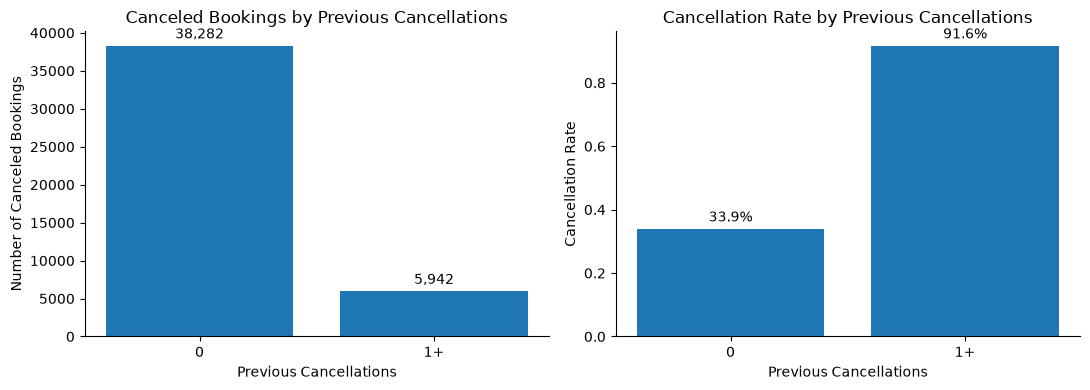

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))

filtered_columns = clean_df[['previous_cancellations', 'is_canceled']].copy()

previous_cancellations_bins = [-1, 0, float('inf')]
previous_cancellations_labels = ['0', '1+']

previous_cancellations_summary = (
    filtered_columns
        .assign(
            previous_cancellations_group=pd.cut(
                filtered_columns['previous_cancellations'], 
                bins=previous_cancellations_bins,
                labels=previous_cancellations_labels,
                right=True
            )
        )
        .groupby('previous_cancellations_group', observed=True)['is_canceled']
        .agg(['count', 'sum', 'mean'])
)

bar_1 = axes[0].bar(
    previous_cancellations_summary.index,
    previous_cancellations_summary['sum'].values
)

axes[0].bar_label(bar_1, fmt='{:,.0f}', padding=3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[0].set_title('Canceled Bookings by Previous Cancellations')
axes[0].set_xlabel('Previous Cancellations')
axes[0].set_ylabel('Number of Canceled Bookings')


bar_2 = axes[1].bar(
    previous_cancellations_summary.index,
    previous_cancellations_summary['mean'].values
)

axes[1].bar_label(bar_2, fmt='{:,.1%}', padding=3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

axes[1].set_title('Cancellation Rate by Previous Cancellations')
axes[1].set_xlabel('Previous Cancellations')
axes[1].set_ylabel('Cancellation Rate')

plt.tight_layout()
plt.show()

### 과거 정상 예약 이력에 따른 현재 예약 취소율
`previous_bookings_not_canceled`이 1회 이상인 예약은 전체 3,620건이며, 이 중 200건이 취소되어 5.5%의 취소율을 보였다. 과거 정상 예약 이력이 없는 그룹의 취소율 38.0%보다 낮게 관찰되었다.

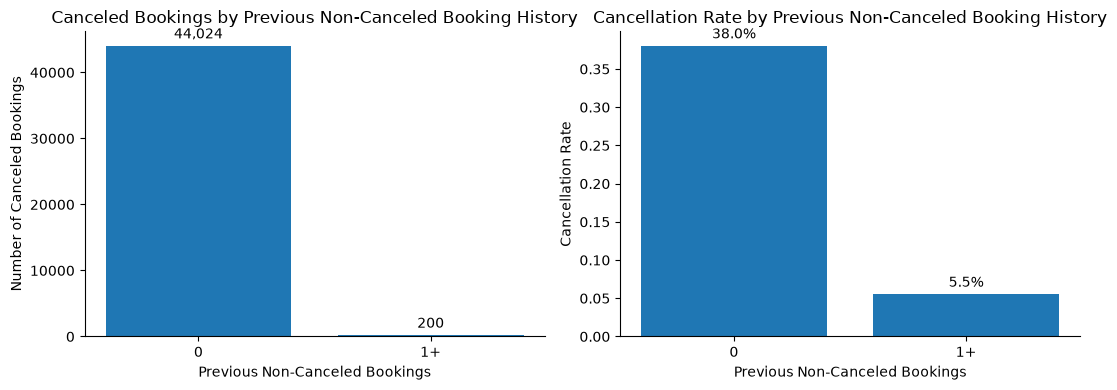

,count,sum,mean
previous_bookings_not_canceled_group,,,
0,115770,44024,0.380271
1+,3620,200,0.055249


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))

filtered_columns = clean_df[['previous_bookings_not_canceled', 'is_canceled']].copy()

previous_bookings_not_canceled_bins = [-1, 0, float('inf')]
previous_bookings_not_canceled_labels = ['0', '1+']

previous_bookings_not_canceled_summary = (
    filtered_columns
        .assign(
            previous_bookings_not_canceled_group=pd.cut(
                filtered_columns['previous_bookings_not_canceled'], 
                bins=previous_bookings_not_canceled_bins,
                labels=previous_bookings_not_canceled_labels,
                right=True
            )
        )
        .groupby('previous_bookings_not_canceled_group', observed=True)['is_canceled']
        .agg(['count', 'sum', 'mean'])
)

bar_1 = axes[0].bar(
    previous_bookings_not_canceled_summary.index,
    previous_bookings_not_canceled_summary['sum'].values
)

axes[0].bar_label(bar_1, fmt='{:,.0f}', padding=3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


bar_2 = axes[1].bar(
    previous_bookings_not_canceled_summary.index,
    previous_bookings_not_canceled_summary['mean'].values
)

axes[1].bar_label(bar_2, fmt='{:,.1%}', padding=3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

axes[0].set_title(
    'Canceled Bookings by Previous Non-Canceled Booking History'
)
axes[0].set_xlabel('Previous Non-Canceled Bookings')
axes[0].set_ylabel('Number of Canceled Bookings')

axes[1].set_title(
    'Cancellation Rate by Previous Non-Canceled Booking History'
)
axes[1].set_xlabel('Previous Non-Canceled Bookings')
axes[1].set_ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

previous_bookings_not_canceled_summary

### 예약구성원에 따른 취소 비교
`adults`, `children`, `babies`와 취소 관계를 확인하려고 했으나, 데이터를 요약해서 보았을 때 유의미한 차이를 보여주지 않아서 넘어가기로 함.

In [39]:
filtered_columns = clean_df[
    ['adults', 'children', 'babies', 'is_canceled']
].copy()

filtered_columns[['adults', 'children', 'babies']].describe()

filtered_columns[
    ['adults', 'children', 'babies']
].value_counts().head(20)

(
    filtered_columns
        .groupby('adults')['is_canceled']
        .agg(['count', 'mean'])
        .sort_index()
)

,count,mean
adults,,
0,403,0.270471
1,23027,0.289834
2,89680,0.393153
3,6202,0.346824
4,62,0.258065
5,2,1.000000
6,1,1.000000
10,1,1.000000
20,2,1.000000


## 결론 및 취소율 감소 방안

EDA 결과, 예약 유형이 `Groups`인 경우 61.1%의 높은 취소율을 보였다. 따라서 단체 예약에는 일정 금액의 예치금을 적용하고, 취소 시점에 따라 환불 금액이 달라지는 단계별 취소 정책을 도입하는 방안을 제안한다.

리드타임이 길어질수록 취소율이 높아지는 패턴도 확인되었다. 특히 180일을 초과한 예약의 취소율은 50% 이상이었다. 장기 예약 고객에게는 일반 요금과 할인 요금제를 함께 제공하되, 할인 요금에는 일정 시점 이후 환불 제한이나 예치금 조건을 적용할 수 있다. 또한 숙박일까지 기간이 긴 만큼 중간에 예약 확인 메시지를 보내 고객이 취소 대신 일정 변경을 선택할 수 있도록 유도하는 방안도 고려할 수 있다.

포르투갈 예약은 장기 리드타임 구간에서 높은 취소율을 보였다. 다만 포르투갈 예약이 전체 데이터에서 차지하는 비중이 크므로, 국적 자체를 취소의 원인으로 단정하기는 어렵다. 따라서 포르투갈 고객에게만 별도의 위약금을 적용하기보다는 포르투갈 예약에서 많이 이용되는 예약 경로와 상품을 추가로 점검하고, 장기 리드타임 예약에 공통적인 예치금 및 예약 재확인 정책을 적용하는 것이 적절하다.

과거 취소 이력이 한 번 이상 있는 예약은 91.6%의 높은 취소율을 보였다. 이러한 예약에는 예약 의사를 다시 확인하거나 예치금이 포함된 요금제를 제시하는 등 추가적인 관리 방안을 검토할 수 있다. 반면 과거 정상 예약 이력이 있는 고객은 취소율이 낮게 나타났으므로, 할인이나 혜택을 제공하여 재예약을 유도하는 방안이 효과적일 수 있다.

또한 예약 변경 이력이 있는 그룹의 취소율이 상대적으로 낮게 나타났다. 따라서 고객이 예약을 바로 취소하지 않고 날짜나 객실 조건을 쉽게 변경할 수 있도록 예약 변경 절차를 간소화하는 것도 취소율을 낮추는 방안으로 제안할 수 있다.